In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ast

In [2]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
log_path = "/home/yanhongwei/DGIL/DGIL/logs/l2p/officecaltech/0/2/CIL_1993_vit_base_patch16_224_l2p.log"

In [4]:
Dataset_DomainName_Mapping = {
    "imageclef": ["i", "p", "c"],
    "domainnet": ["clipart", "infograph", "painting", "quickdraw", "real", "sketch"],
    "minidomainnet": ["clipart", "painting", "real", "sketch"],
    "officehome": ["Art", "Clipart", "Product", "Real World"],
    "office31": ["amazon", "dslr", "webcam"],
    "officecaltech": ["amazon", "caltech", "dslr", "webcam"],
    "digitsdg": ["mnist", "mnist_m", "svhn", "syn"],
    "digitsfive": ["mnist", "mnist_m", "svhn", "syn", "usps"],
    "core50": [f"s{i}" for i in range(1, 12)]
}

In [5]:
average_cnn_prefix = "[trainer.py] => CNN: "
average_nme_prefix = "[trainer.py] => NME: "

for key in Dataset_DomainName_Mapping.keys():
    if f'/{key}/' in log_path:

        domain_names = Dataset_DomainName_Mapping[key]
        domain_cnn_prefix_map = {}
        domain_nme_prefix_map = {}

        for domain_id, domain_name in enumerate(domain_names):
            domain_cnn_prefix_map[f"{domain_name}_cnn"] = f"[trainer.py] => Domain [{domain_id}] {domain_name}: CNN: "
            domain_nme_prefix_map[f"{domain_name}_nme"] = f"[trainer.py] => Domain [{domain_id}] {domain_name}: NME: "

        break

all_prefix_map = {
    "average_cnn": average_cnn_prefix,
    "average_nme": average_nme_prefix,
    **domain_cnn_prefix_map,
    **domain_nme_prefix_map
}

plt.style.use('seaborn-v0_8-talk')

In [6]:
def load_data(file_path, prefix_str):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    acc_dict_ls = []
    for line in lines:
        if prefix_str in line:
            accy_dict_str = line.split(prefix_str)[1]
            accy_dict = ast.literal_eval(accy_dict_str)
            acc_dict_ls.append(accy_dict)
    return acc_dict_ls

def split_data(acc_dict_ls):
    acc_ls_dict = {}
    for acc_dict in acc_dict_ls:
        for key, value in acc_dict.items():
            if key not in acc_ls_dict:
                acc_ls_dict[key] = []
            acc_ls_dict[key].append(value)
    return acc_ls_dict

def load_domain_data(file_path, prefix_str_ls):
    domain_acc_dict_ls = {domain_name: [] for domain_name in domain_names}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        for prefix_str in prefix_str_ls:
            if prefix_str in line:
                for domain_id, domain_name in enumerate(domain_names):
                    if f"[trainer.py] => Domain [{domain_id}] {domain_name}:" in line:
                        accy_dict_str = line.split(prefix_str)[1]
                        accy_dict = ast.literal_eval(accy_dict_str)
                        domain_acc_dict_ls[domain_name].append(accy_dict)
    return domain_acc_dict_ls

def split_domain_data(domain_acc_dict_ls):
    domain_acc_ls_dict = {domain_name: {} for domain_name in domain_names}
    for domain_name, acc_dict_ls in domain_acc_dict_ls.items():
        for acc_dict in acc_dict_ls:
            for key, value in acc_dict.items():
                if key not in domain_acc_ls_dict[domain_name]:
                    domain_acc_ls_dict[domain_name][key] = []
                domain_acc_ls_dict[domain_name][key].append(value)
    return domain_acc_ls_dict

In [7]:
def plot_global_acc(acc_ls_dict, title = 'Global Accuracy'):
    plt.figure(figsize=(10, 5))

    total_acc_ls = acc_ls_dict['total']
    old_acc_ls = acc_ls_dict['old']
    new_acc_ls = acc_ls_dict['new']
    plt.plot(total_acc_ls, label='Total Accuracy', linewidth=2, marker='o')
    plt.plot(old_acc_ls, label='Old Accuracy', linewidth=2, marker='o')
    plt.plot(new_acc_ls, label='New Accuracy', linewidth=2, marker='o')

    plt.xlabel('Task', fontdict={'size':15})
    plt.ylabel('Accuracy(%)', fontdict={'size':15})
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 100)
    plt.legend(fontsize=14)
    plt.title(title, fontdict={'size':15})
    plt.show()

def plot_task_acc(acc_ls_dict, title = 'Task-wise Accuracy'):
    plt.figure(figsize=(10, 5))

    task_num = len(acc_ls_dict['total'])
    for task_id, acc_ls in acc_ls_dict.items():
        if '-' in task_id:
            acc_ls_task = acc_ls_dict[task_id]
            start_task = task_num - len(acc_ls_task)
            plt.plot(range(start_task, start_task+len(acc_ls_task)), acc_ls_task, label=task_id, linewidth=2, marker='o')

    plt.xlabel('Task', fontdict={'size':15})
    plt.ylabel('Accuracy(%)', fontdict={'size':15})
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 100)
    plt.legend(fontsize=14)
    plt.title(title, fontdict={'size':15})
    plt.show()

def plot_domain_acc(domain_acc_ls_dict, key='total'):

    plt.figure(figsize=(10, 5))

    for domain in domain_names:
        acc_ls = domain_acc_ls_dict[domain][key]
        plt.plot(acc_ls, label=domain, linewidth=2, marker='o')

    plt.xlabel('Task', fontdict={'size':15})
    plt.ylabel('Accuracy(%)', fontdict={'size':15})
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 100)
    plt.legend(fontsize=14)
    plt.title(f'Domain-wise Accuracy ({key})', fontdict={'size':15})
    plt.show()

In [8]:
def plot_all_acc_data(log_path, all_prefix_map, cls_head="cnn"):
    for prefix_name, prefix in all_prefix_map.items():
        if f"_{cls_head}" in prefix_name:
            acc_dict_ls = load_data(log_path, prefix)
            acc_ls_dict = split_data(acc_dict_ls)
            plot_global_acc(acc_ls_dict, f"Global Acc of {prefix_name}")
            # plot_task_acc(acc_ls_dict, f"Task Acc of {prefix_name}")

def plot_domain_wise_acc_data(log_path, all_prefix_map, cls_head="cnn"):
    prefix_str_ls = []
    for prefix_name, prefix in all_prefix_map.items():
        for domain_name in domain_names:
            if f"{domain_name}_{cls_head}" in prefix_name:
                prefix_str_ls.append(prefix)
    domain_acc_dict_ls = load_domain_data(log_path, prefix_str_ls)
    domain_acc_ls_dict = split_domain_data(domain_acc_dict_ls)
    plot_domain_acc(domain_acc_ls_dict, key='total')
    plot_domain_acc(domain_acc_ls_dict, key='old')
    plot_domain_acc(domain_acc_ls_dict, key='new')

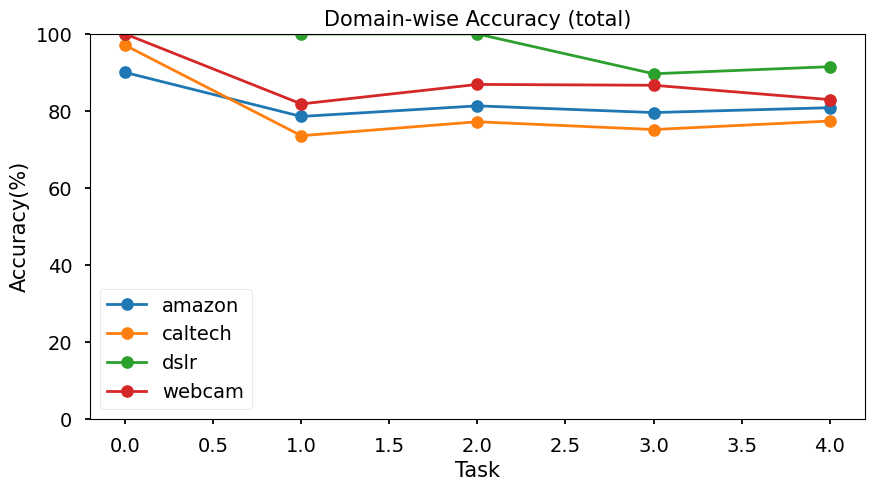

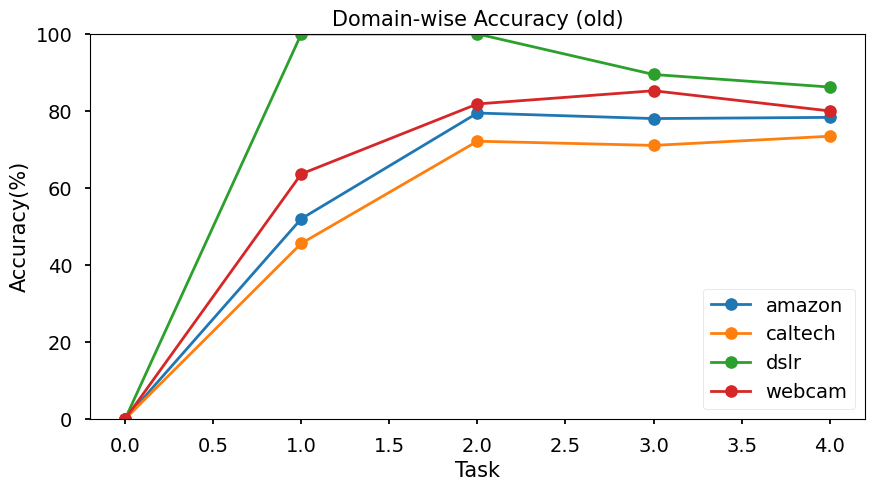

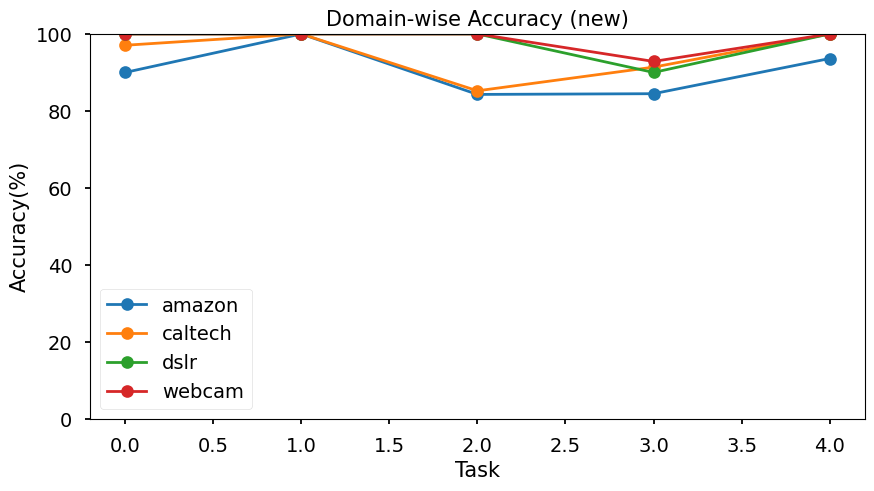

In [9]:
# plot_all_acc_data(log_path, all_prefix_map, cls_head="cnn")
plot_domain_wise_acc_data(log_path, all_prefix_map, cls_head="cnn")

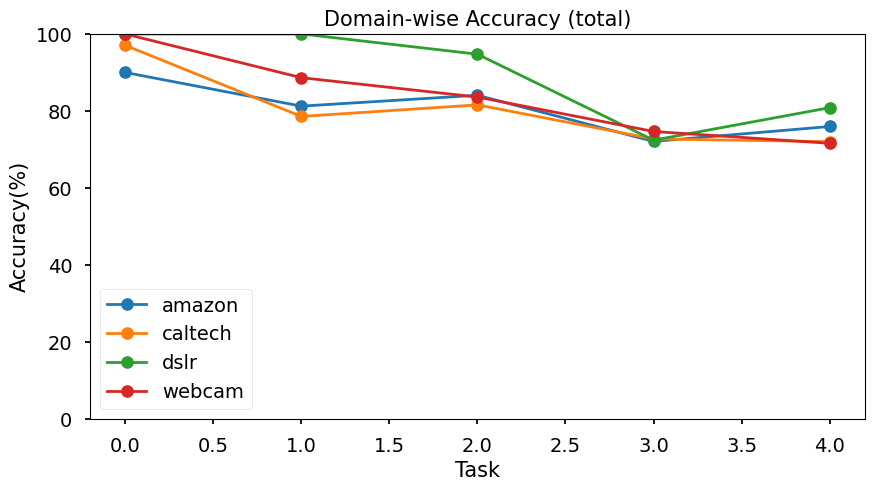

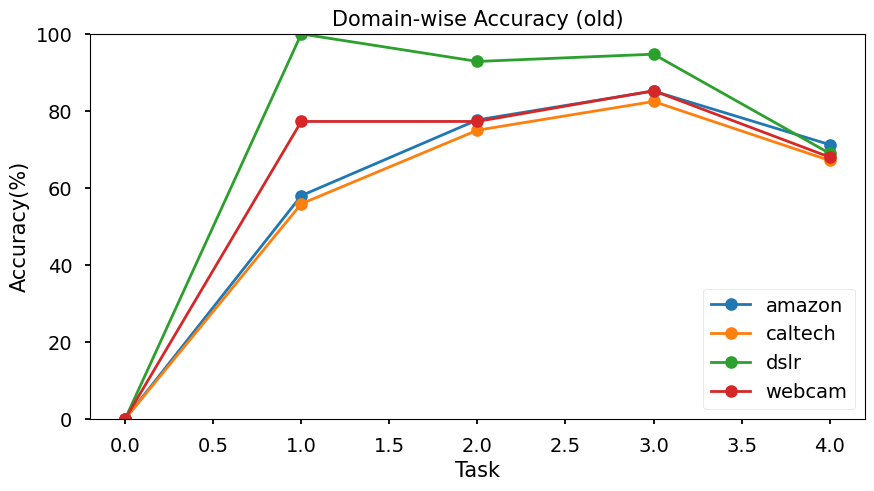

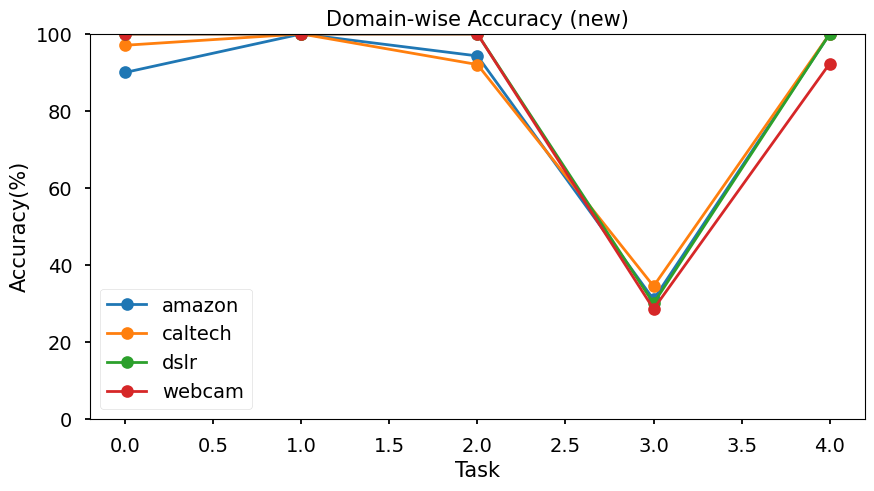

In [10]:
log_path = "/home/yanhongwei/DGIL/DGIL/logs/l2p/officecaltech/0/2/DGIL_1993_vit_base_patch16_224_l2p.log"
plot_domain_wise_acc_data(log_path, all_prefix_map, cls_head="cnn")

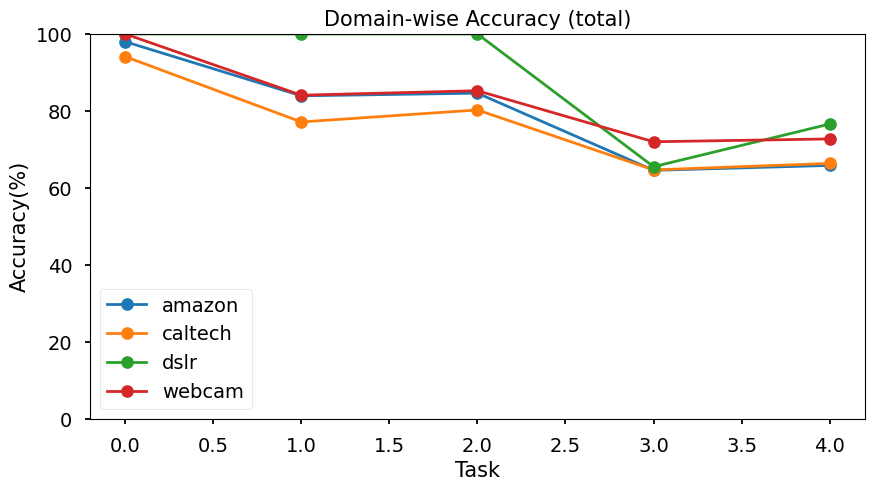

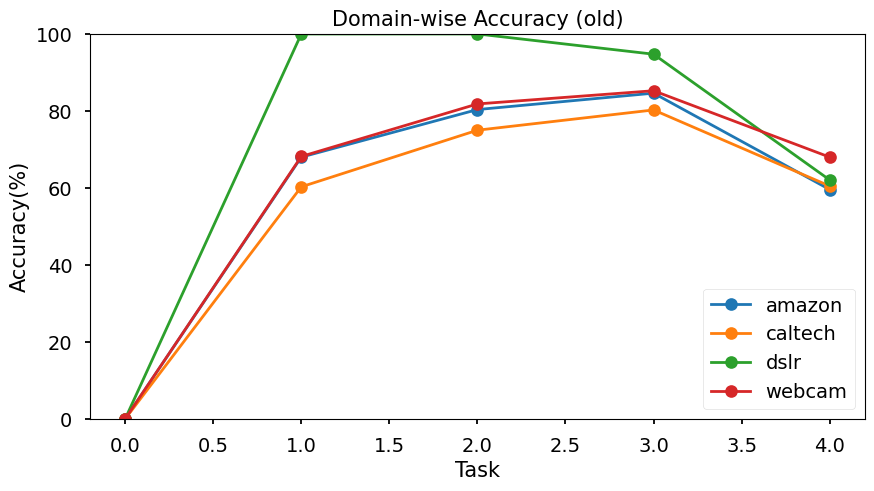

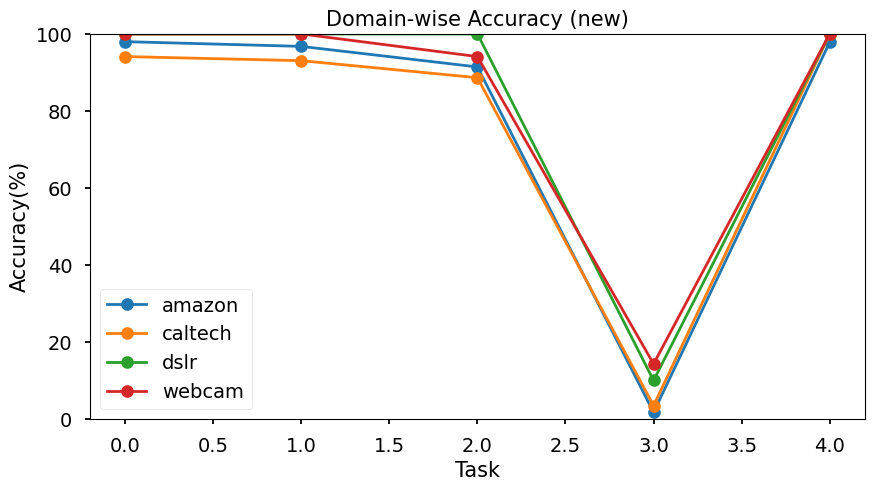

In [11]:
log_path = "/home/yanhongwei/DGIL/DGIL/logs/l2p/officecaltech/0/2/DGIL_v2_1993_vit_base_patch16_224_l2p.log"
plot_domain_wise_acc_data(log_path, all_prefix_map, cls_head="cnn")

In [11]:
# save the results as a csv file
import os
import pandas as pd

root_folder = "/home/liyuan/DGIL/logs"
all_result = []
for root, dirs, files in os.walk(root_folder):
    for file in files:
        if file.endswith(".log"):
            result_dict = {}
            log_file = os.path.join(root, file)
            with open(log_file, 'r') as f:
                lines = f.readlines()
            result_dict["model_name"] = ""
            result_dict["dataset"] = ""
            result_dict["prefix"] = ""
            result_dict["acc"] = 0.0
            result_dict["forgetting"] = 0.0
            for line in lines:
                if "[trainer.py] => model_name:" in line:
                    result_dict["model_name"] = line.split(":")[-1].strip()
                if "[trainer.py] => prefix" in line:
                    result_dict["prefix"] = line.split(":")[-1].strip()
                if "[trainer.py] => dataset:" in line:
                    result_dict["dataset"] = line.split(":")[-1].strip()
                if "[trainer.py] => Average Accuracy (CNN):" in line:
                    result_dict["acc"] = float(line.split(":")[-1].strip())
                if "[trainer.py] => Forgetting (CNN):" in line:
                    result_dict["forgetting"] = float(line.split(":")[-1].strip())
            all_result.append(result_dict)

# rearange the contents of the csv file in the following form:
# method | prefix | dataset | acc | forgetting
# and the prefix order is: CIL, DGIL, DGIL_v2
df = pd.DataFrame(all_result)
df = df[["model_name", "prefix", "dataset", "acc", "forgetting"]]
df = df.sort_values(by=["model_name", "dataset", "prefix"])
df.to_csv("results.csv", index=False)
